In [1]:
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader

import numpy as np
from pathlib import Path
from __future__ import annotations

import v1.CarImageClass as CarImageClass
from v1.SSD_trainer import ConditionalIoUCrop, collate_detection, plot_losses, build_optimizer_and_scheduler


from v1.SSD_from_scratch import mySSD as oldSSD
from v1.SSD_trainer import SSD_train as oldSSD_train

from v2.model_files.SSD_from_scratch import mySSD as newSSD
from v2.training_files.SSD_trainer import SSD_train as newSSD_train
from v2.training_files.save_load_ckpt import load_checkpoint
from v2.training_files.plot_losses import plot_losses
from v2.training_files.build_dataloaders import build_train_dl, build_test_dl



device = "cuda" if torch.cuda.is_available() else "cpu"

# desktop, laptop, ubuntu
machine = 'ubuntu'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
elif machine == 'desktop':
    folder_path = Path(r"C:\Udacity_car_data\data")
elif machine == 'ubuntu':
    folder_path = Path(r"/mnt/c/Udacity_car_data/data")

train_path = folder_path / "train"
test_path = folder_path / "test"

In [4]:
# transforms
train_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.RandomZoomOut(fill=0, p=0.5),       # Zoom out hurts model performance

    ConditionalIoUCrop(min_area_frac=0.02,   # threshold between "large" and "small"
                       small_min_scale=0.4,
                       large_min_scale=0.7,
                       max_scale=1.0,
                       min_aspect_ratio=0.75,
                       max_aspect_ratio=1.33,
                       small_sampler_options=(0.0, 0.05, 0.1, 2.0),
                       large_sampler_options=(0.05, 0.1, 0.3, 2.0),
                       trials=10),

    v2.SanitizeBoundingBoxes(min_size=1.0),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomPhotometricDistort(p=0.5),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_tfms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((300, 300), antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

# 993 images
train_data = CarImageClass.ImageClass(targ_dir=train_path, transform=train_tfms, file_pct=0.05, rand_seed=724, include_area=False)
val_data = CarImageClass.ImageClass(targ_dir=train_path, transform=test_tfms, file_pct=0.05, rand_seed=412, include_area=False)

# need to put dataloaders on cpu to use pin_memory
BATCH_SIZE = 16
NUM_WORKERS = 8
# Create DataLoader's
train_dataloader = DataLoader(train_data, 
                              batch_size=BATCH_SIZE, 
                              shuffle=True, 
                              num_workers=NUM_WORKERS,
                              persistent_workers=True,
                              prefetch_factor=2,
                              pin_memory=True,
                              collate_fn=collate_detection,
                              multiprocessing_context=None,
                              )

val_dataloader = DataLoader(val_data, 
                            batch_size=BATCH_SIZE, 
                            shuffle=False,
                            num_workers=NUM_WORKERS,
                            persistent_workers=True,
                            prefetch_factor=2,
                            pin_memory=True,
                            collate_fn=collate_detection,
                            multiprocessing_context=None,
                            )


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0  |  mAP: 0.0032  |  Train loc loss: 4.3285  |  Train class loss: 5.5631  |  Test loc loss: 4.0173  |  Test class loss: 3.7409
Epoch: 1  |  mAP: 0.0118  |  Train loc loss: 3.3490  |  Train class loss: 3.2290  |  Test loc loss: 3.1382  |  Test class loss: 2.9774
Epoch: 2  |  mAP: 0.0001  |  Train loc loss: 2.6843  |  Train class loss: 2.9314  |  Test loc loss: 4.8671  |  Test class loss: 13.6761
Epoch: 3  |  mAP: 0.0001  |  Train loc loss: 2.6083  |  Train class loss: 3.1148  |  Test loc loss: 4.5622  |  Test class loss: 3.8339
Epoch: 4  |  mAP: 0.0163  |  Train loc loss: 2.4198  |  Train class loss: 2.7079  |  Test loc loss: 2.5879  |  Test class loss: 3.0635
Epoch: 5  |  mAP: 0.0001  |  Train loc loss: 2.0382  |  Train class loss: 2.4296  |  Test loc loss: 4.1506  |  Test class loss: 7.7765
Epoch: 6  |  mAP: 0.0104  |  Train loc loss: 2.7454  |  Train class loss: 3.3092  |  Test loc loss: 2.8003  |  Test class loss: 3.5914
Epoch: 7  |  mAP: 0.0211  |  Train loc loss: 2.0674  |

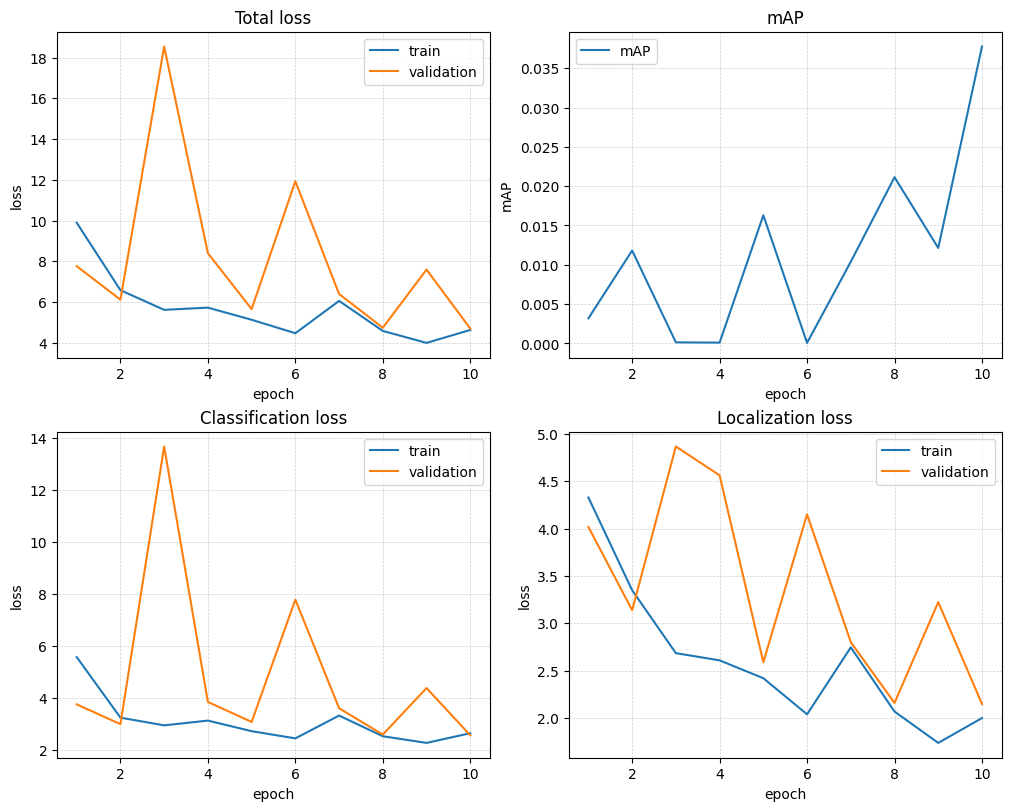

In [5]:
old_ssdmodel = oldSSD(class_to_idx_dict=train_data.class_to_idx, in_channels=3, variances=(0.1, 0.2)).to(device)

old_optimizer, old_scheduler = build_optimizer_and_scheduler(model=old_ssdmodel,
                                                     train_dataloader=train_dataloader,
                                                     max_epochs=150,
                                                     warmup_epochs=5,
                                                     base_lr=0.003,
                                                     min_lr=1e-6,
                                                     momentum=0.9,
                                                     weight_decay=0.005)

# new model only
# scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

old_results = oldSSD_train(model=old_ssdmodel,
                    train_dataloader=train_dataloader,
                    test_dataloader=val_dataloader,
                    optimizer=old_optimizer,
                    scheduler=old_scheduler,
                    sched_step_w_opt=True,
                    iou_thresh=0.4,
                    neg_pos_ratio=3.0,
                    score_thresh=0.2,
                    nms_thresh=0.3,
                    max_detections_per_img=100,
                    epochs=10,
                    early_stopping_rounds=None,
                    device=device,
                    save_model=False,
                    epoch_save_interval=None,
                    SAVE_DIR=None,
                    timing=True,
                    past_train_dict=None,
                    )

plot_losses(old_results)

  0%|          | 0/10 [00:00<?, ?it/s]

/home/eblackstone/repos/ssd-venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Epoch: 1  |  mAP: 0.0039  |  Train loc loss: 4.3882  |  Train class loss: 5.8232  |  Test loc loss: 4.0167  |  Test class loss: 3.7089
Epoch: 2  |  mAP: 0.0123  |  Train loc loss: 3.3229  |  Train class loss: 3.2396  |  Test loc loss: 3.2472  |  Test class loss: 3.1010
Epoch: 3  |  mAP: 0.0115  |  Train loc loss: 2.7115  |  Train class loss: 2.8139  |  Test loc loss: 3.3579  |  Test class loss: 4.0265
Epoch: 4  |  mAP: 0.0056  |  Train loc loss: 2.4142  |  Train class loss: 2.7343  |  Test loc loss: 2.6977  |  Test class loss: 3.9858
Epoch: 5  |  mAP: 0.0099  |  Train loc loss: 2.1412  |  Train class loss: 2.6395  |  Test loc loss: 2.7401  |  Test class loss: 4.3553
Epoch: 6  |  mAP: 0.0318  |  Train loc loss: 1.8459  |  Train class loss: 2.3549  |  Test loc loss: 2.3680  |  Test class loss: 2.7995
Epoch: 7  |  mAP: 0.0289  |  Train loc loss: 1.6626  |  Train class loss: 2.1651  |  Test loc loss: 2.1397  |  Test class loss: 2.4177
Epoch: 8  |  mAP: 0.0283  |  Train loc loss: 1.5866  | 

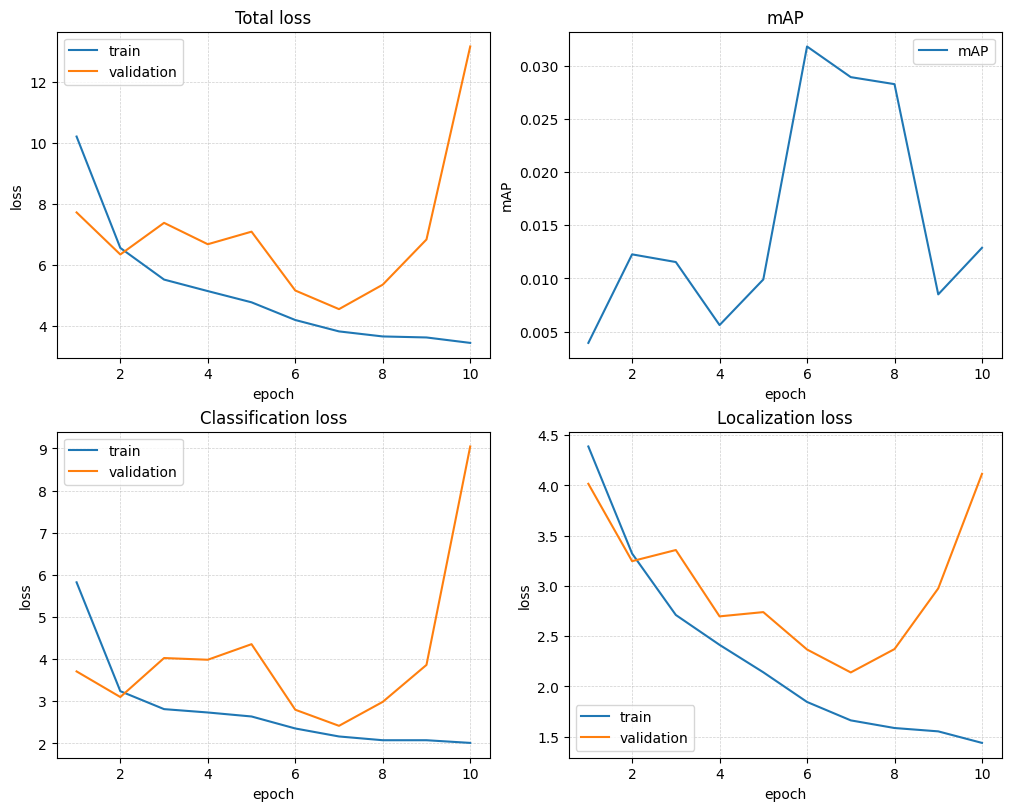

In [6]:
new_ssdmodel = newSSD(class_to_idx_dict=train_data.class_to_idx, in_channels=3, variances=(0.1, 0.2)).to(device)

train_dataloader = DataLoader(train_data, 
                              batch_size=16, 
                              shuffle=True, 
                              num_workers=4,
                              persistent_workers=True,
                              prefetch_factor=4,
                              pin_memory=True,
                              collate_fn=collate_detection,
                              multiprocessing_context=None,
                              )

val_dataloader = DataLoader(val_data, 
                            batch_size=16, 
                            shuffle=False,
                            num_workers=4,
                            persistent_workers=True,
                            prefetch_factor=4,
                            pin_memory=True,
                            collate_fn=collate_detection,
                            multiprocessing_context=None,
                            )

new_optimizer, new_scheduler = build_optimizer_and_scheduler(model=new_ssdmodel,
                                                     train_dataloader=train_dataloader,
                                                     max_epochs=150,
                                                     warmup_epochs=5,
                                                     base_lr=0.003,
                                                     min_lr=1e-6,
                                                     momentum=0.9,
                                                     weight_decay=0.005)

# new model only
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

new_results = newSSD_train(model=new_ssdmodel,
                    train_dataloader=train_dataloader,
                    test_dataloader=val_dataloader,
                    optimizer=new_optimizer,
                    scheduler=new_scheduler,
                    scaler=scaler,
                    sched_step_w_opt=True,
                    iou_thresh=0.4,
                    iou_variant="DIoU",
                    neg_pos_ratio=3.0,
                    score_thresh=0.2,
                    nms_thresh=0.3,
                    max_detections_per_img=200,
                    epochs=10,
                    early_stopping_rounds=None,
                    device=device,
                    save_model=False,
                    epoch_save_interval=None,
                    SAVE_DIR=None,
                    timing=True,
                    past_train_dict=None,
                    compute_mAP=True,
                    )

plot_losses(new_results)

In [7]:
avg_old_train = {
    k: round(sum(d[k] for d in old_results['training timing']) / len(old_results['training timing']),5)
    for k in old_results['training timing'][0]
}

avg_old_test = {
    k: round(sum(d[k] for d in old_results['testing timing']) / len(old_results['testing timing']),5)
    for k in old_results['testing timing'][0]
}


print(f"Old training: {avg_old_train}")
print(f"Old testing: {avg_old_test}")

Old training: {'to device': 0.00212, 'model forward': 0.09755, 'build targets': 0.03512}
Old testing: {'to device': 0.00201, 'model forward': 0.11334, 'build targets': 0.03276, 'compute loss': 0.00538, 'model.predict': 0.79435, 'mAP time': 5.76212}


In [8]:
avg_new_train = {
    k: round(sum(d[k] for d in new_results['training timing']) / len(new_results['training timing']),5)
    for k in new_results['training timing'][0]
}

avg_new_test = {
    k: round(sum(d[k] for d in new_results['testing timing']) / len(new_results['testing timing']),5)
    for k in new_results['testing timing'][0]
}


print(f"New training: {avg_new_train}")
print(f"New testing: {avg_new_test}")

New training: {'to device': 0.0016, 'model forward': 0.05778, 'build targets': 0.01226, 'compute loss': 0.00352}
New testing: {'to device': 0.00274, 'model forward': 0.05191, 'build targets': 0.00833, 'compute loss': 0.00295, 'model.predict': 0.04813, 'mAP time': 9.20766}
